In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
a=pd.read_excel("knn2.xlsx")
a.head(4)


,month,load(Mw),class
0,4,40,0
1,6,50,0
2,7,80,0
3,10,100,0


In [7]:
b = {0: 'Low', 1: 'High'}
a['class'] = a['class'].map(b)
x = a[['month', 'load(Mw)']]
y = a['class']
print(x.head())

   month  load(Mw)
0      4        40
1      6        50
2      7        80
3     10       100
4     12       120


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(y_pred)

['High' 'Low' 'Low']


In [12]:
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy Score: {accuracy:.2%}")
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Accuracy Score: 100.00%
Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1
         Low       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



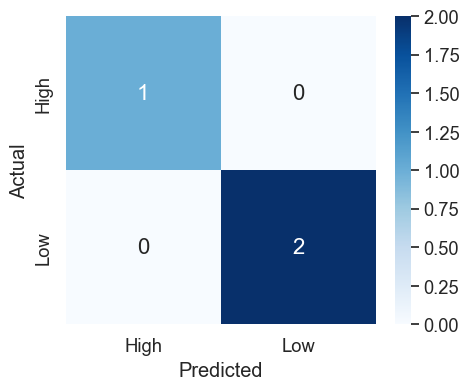

In [14]:
import seaborn as sn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm_data = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm_data, columns=np.unique(y_test), index=np.unique(y_test))

df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'

plt.figure(figsize=(5, 4))
sn.set(font_scale=1.2)
sn.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16})
plt.show()